# Ventas de videojuegos

Nombre: Alejandra Ñanculeo

Sección: 004D

## Contexto

El dataset utilizado corresponde a un registro histórico de videojuegos que han superado las 100.000 copias vendidas. La información incluye nombre del videojuego, plataforma, género, año de lanzamiento, editor y ventas registradas en distintas regiones del mundo, incluyendo Norteamérica, Europa, Japón y otras regiones. El conjunto de datos permite analizar patrones de ventas y aplicar técnicas de minería de datos orientadas al descubrimiento de conocimiento y la predicción.

## Introducción

El objetivo de este trabajo es aplicar técnicas de minería de datos sobre un conjunto de datos de videojuegos para identificar patrones de comportamiento, relaciones entre variables y generar modelos predictivos. Para ello se realizará un proceso de exploración, limpieza, transformación y modelado utilizando algoritmos de clasificación estudiados durante la asignatura.

In [35]:
#cargamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [36]:
#Probamos el dataset
df = pd.read_csv('vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [37]:
df.shape

(16598, 11)

In [38]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [39]:
df.duplicated().sum()

np.int64(0)

A través de esto, podemos ver una cantidad de 329 nulos

*   Year → 271 nulos
*   Publisher → 58 nulos

¿Qué hacemos con ellos?

In [40]:
df['Year'] = df['Year'].fillna(df['Year'].median())

df['Publisher'] = df['Publisher'].fillna('Desconocido')

In [41]:
#verificamos
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


Acabando con la limpieza del dataset, empezamos con los gráficos.

## Gráficos

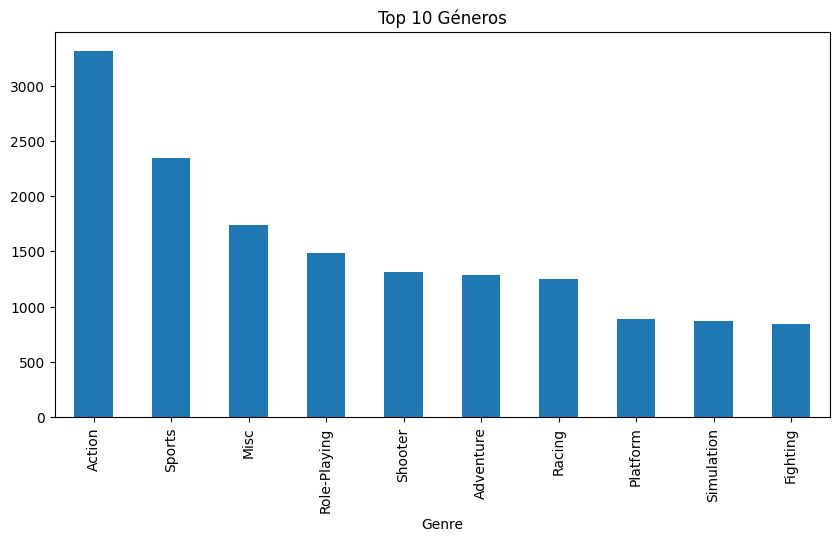

In [42]:
#Top 10 géneros
plt.figure(figsize=(10,5))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Géneros')
plt.show()

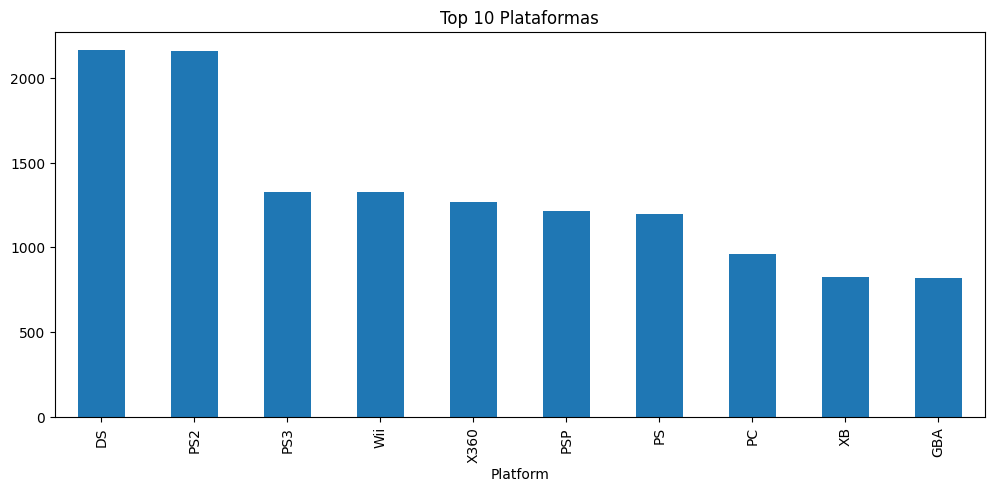

In [43]:
#Plataformas más usadas
plt.figure(figsize=(12,5))

df['Platform'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Plataformas')
plt.show()

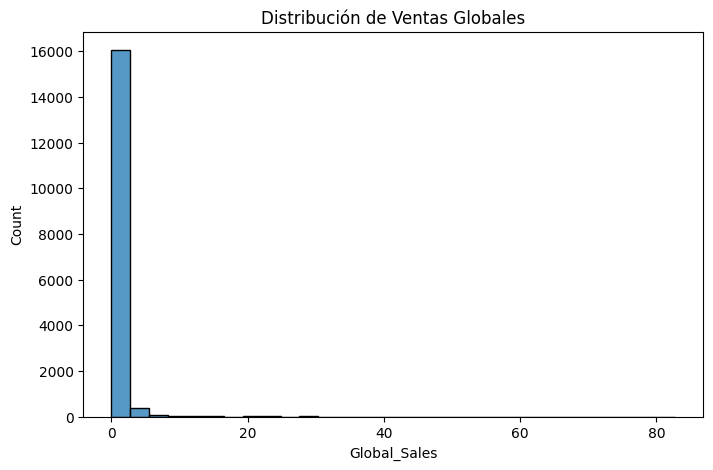

In [44]:
#Distribución de ventas gobales
plt.figure(figsize=(8,5))

sns.histplot(df['Global_Sales'], bins=30)

plt.title('Distribución de Ventas Globales')
plt.show()

##Encoding

Las categorias que vamos a encodear son:

*   Platform
*   Genre
*   Publisher

In [45]:
platform_encoder = LabelEncoder()
genre_encoder = LabelEncoder()
publisher_encoder = LabelEncoder()

df['Platform_Encoded'] = platform_encoder.fit_transform(df['Platform'])

df['Genre_Encoded'] = genre_encoder.fit_transform(df['Genre'])

df['Publisher_Encoded'] = publisher_encoder.fit_transform(df['Publisher'])

##Correlación

In [46]:
corr_df = df[[
    'Year',
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales',
    'Platform_Encoded',
    'Genre_Encoded'
]]

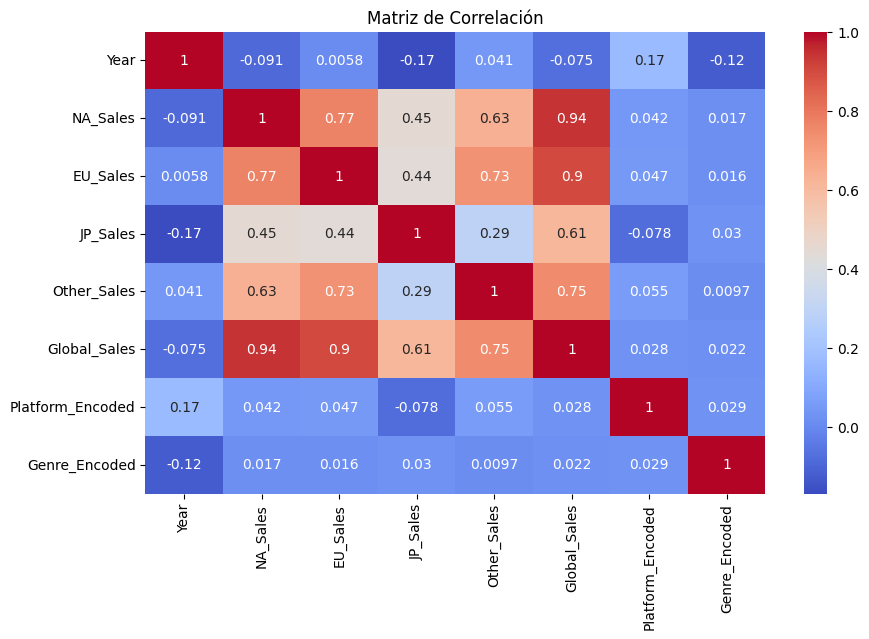

In [47]:
corr = corr_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Matriz de Correlación')
plt.show()

##Interpretación

Podemos ver que Global_Sales está altamente correlacionada con NA_Sales y EU_Sales, lo cual es normal porque Global_Sales es la suma.

##Variable objetivo
Vamos a crear categorías de ventas:

In [48]:
df['Sales_Category'] = pd.qcut(
    df['Global_Sales'],
    q=3,
    labels=['Baja','Media','Alta']
)

In [49]:
#y la encodeamos
target_encoder = LabelEncoder()

df['Sales_Category_Encoded'] = target_encoder.fit_transform(
    df['Sales_Category']
)

##Variables predictorias

In [50]:
X = df[[
    'Year',
    'Platform_Encoded',
    'Genre_Encoded',
    'Publisher_Encoded',
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales'
]]

y = df['Sales_Category_Encoded']

##Train Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Árbol de Decisión

In [52]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(
    "Accuracy Árbol:",
    accuracy_score(y_test,y_pred_tree)
)

Accuracy Árbol: 0.9743975903614458


##Naive Bayes

In [53]:
nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

y_pred_nb = nb_model.predict(X_test)

print(
    "Accuracy Naive Bayes:",
    accuracy_score(y_test,y_pred_nb)
)

Accuracy Naive Bayes: 0.8855421686746988


##SVM

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC()

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_scaled
)

print(
    "Accuracy SVM:",
    accuracy_score(y_test,y_pred_svm)
)

Accuracy SVM: 0.9463855421686747


##Comparación de Accuracy

In [55]:
print("Árbol de Decisión:", accuracy_score(y_test, y_pred_tree))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Árbol de Decisión: 0.9743975903614458
Naive Bayes: 0.8855421686746988
SVM: 0.9463855421686747


##Matriz de Confusión

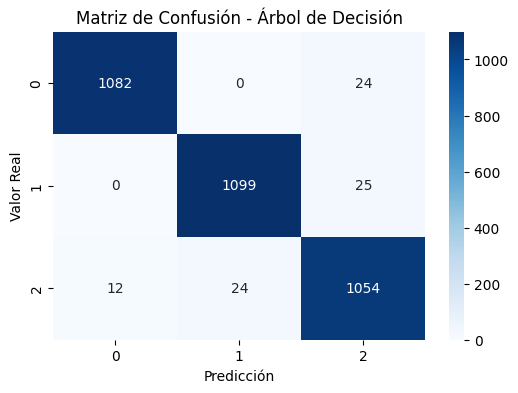

In [56]:
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [57]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1106
           1       0.98      0.98      0.98      1124
           2       0.96      0.97      0.96      1090

    accuracy                           0.97      3320
   macro avg       0.97      0.97      0.97      3320
weighted avg       0.97      0.97      0.97      3320



##Interpretación
La matriz de confusión muestra que la mayoría de los videojuegos fueron clasificados correctamente dentro de su categoría de ventas. Los valores más altos se concentran en la diagonal principal, indicando una elevada cantidad de predicciones correctas. Los errores de clasificación fueron reducidos, lo que confirma el buen desempeño del modelo seleccionado.


In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_cluster = df[[
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
0    16455
1      142
2        1
Name: count, dtype: int64


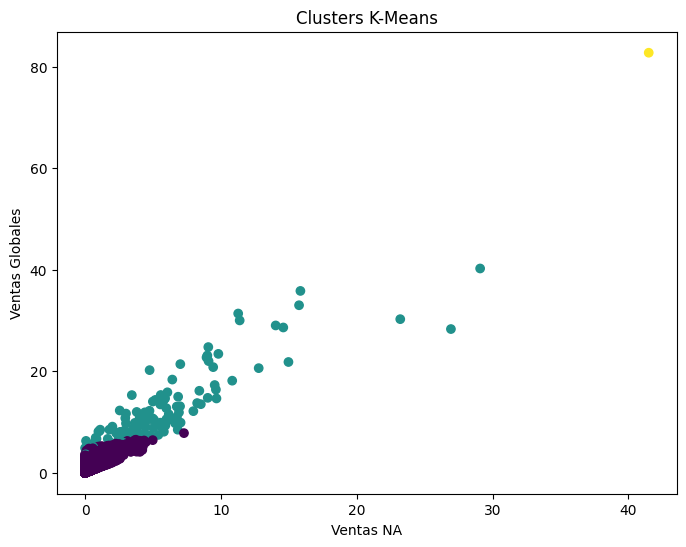

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['NA_Sales'],
    df['Global_Sales'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Ventas NA")
plt.ylabel("Ventas Globales")
plt.title("Clusters K-Means")

plt.show()

In [60]:
import pickle

with open("modelo_arbol.pkl","wb") as f:
    pickle.dump(tree_model,f)

In [61]:
#para probar
qa = X_test.sample(10, random_state=42)

qa.to_csv("dataset_QA.csv", index=False)

In [62]:
import pickle

with open("modelo.pkl", "wb") as archivo:
    pickle.dump(tree_model, archivo)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


##Web Scraping

In [63]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_best-selling_video_games"

response = requests.get(url)

if response.status_code == 200:

    soup = BeautifulSoup(response.text, "html.parser")

    tabla = soup.find("table", class_="wikitable")

    datos = pd.read_html(str(tabla))[0]

    print(datos.head())

    datos.to_csv("videojuegos_scraping.csv", index=False)

    print("Web Scraping realizado correctamente.")

else:

    print("Error al acceder a la página.")

Error al acceder a la página.


El Web Scraping se utilizó para obtener información adicional sobre los videojuegos más vendidos desde Wikipedia, permitiendo complementar el análisis con datos externos.

##API con Flask

In [64]:
# from flask import Flask, request, jsonify
# import pickle
# import numpy as np

# app = Flask(__name__)

# modelo = pickle.load(open("modelo.pkl", "rb"))

# @app.route("/")
# def inicio():

#     return "API del modelo de Minería de Datos funcionando."

# @app.route("/predict", methods=["POST"])

# def predict():

#     datos = request.json

#     entrada = np.array([[
#         datos["NA_Sales"],
#         datos["EU_Sales"],
#         datos["JP_Sales"],
#         datos["Other_Sales"]
#     ]])

#     prediccion = modelo.predict(entrada)

#     return jsonify({
#         "Prediccion": int(prediccion[0])
#     })

# if __name__ == "__main__":

#     app.run(debug=True)